# Retrieval Results Visualization

Notebook for visualizing outputs from the parallel retrieval workflow (`parallel_cli` / `scripts/slurm/run_retrieval_parallel.sh`).

Default configuration in this notebook:
- `OUTPUT_PREFIX = "my_run_fast"`
- `RESULTS_SUBDIR = "full"`
            


In [25]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError(
        "This notebook requires seaborn. Install with: uv add seaborn or pip install seaborn"
    ) from exc

from IPython.display import display

sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={
        "figure.facecolor": "white",
        "axes.facecolor": "#F8FAFC",
        "axes.edgecolor": "#D1D5DB",
        "grid.color": "#E5E7EB",
        "axes.titleweight": "bold",
    },
)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
            


In [26]:
# --- Run configuration ---
OUTPUT_PREFIX = "my_run_fast"
RESULTS_SUBDIR = "full"  # "full" or "subsample"

# Performance tuning for large detail tables.
DETAIL_SAMPLE_PER_GROUP = 4000
RANDOM_STATE = 7

candidate_roots = [Path("."), Path("..")]
results_dir = None
for root in candidate_roots:
    candidate = (root / "results" / RESULTS_SUBDIR).resolve()
    if candidate.exists():
        results_dir = candidate
        break

if results_dir is None:
    raise FileNotFoundError(
        "Could not find results directory. Expected ./results/{subdir} or ../results/{subdir}."
    )


def read_csv_required(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")
    return pd.read_csv(path)


def read_csv_optional(path: Path) -> pd.DataFrame:
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


paths = {
    "summary_overall": results_dir / f"{OUTPUT_PREFIX}_summary_overall.csv",
    "summary_by_cell": results_dir / f"{OUTPUT_PREFIX}_summary_by_cell_type.csv",
    "detail": results_dir / f"{OUTPUT_PREFIX}_detail.csv",
    "tasks": results_dir / f"{OUTPUT_PREFIX}_tasks.csv",
    "truth_summary": results_dir / f"{OUTPUT_PREFIX}_truth_summary.csv",
    "truth_matches": results_dir / f"{OUTPUT_PREFIX}_truth_matches.csv",
}

summary_overall_df = read_csv_required(paths["summary_overall"])
summary_by_cell_df = read_csv_required(paths["summary_by_cell"])
detail_df = read_csv_required(paths["detail"])
tasks_df = read_csv_optional(paths["tasks"])
truth_summary_df = read_csv_optional(paths["truth_summary"])
truth_matches_df = read_csv_optional(paths["truth_matches"])

print(f"Using results directory: {results_dir}")
for key, p in paths.items():
    exists = p.exists()
    size = f"{p.stat().st_size / 1e6:.1f} MB" if exists else "missing"
    print(f"- {key:14s} | exists={str(exists):5s} | {p.name} | {size}")
            


Using results directory: /Users/arturszalata/PycharmProjects/Chem-PerturBridge_analysis/results/full
- summary_overall | exists=True  | my_run_fast_summary_overall.csv | 0.0 MB
- summary_by_cell | exists=True  | my_run_fast_summary_by_cell_type.csv | 0.2 MB
- detail         | exists=True  | my_run_fast_detail.csv | 178.9 MB
- tasks          | exists=True  | my_run_fast_tasks.csv | 0.1 MB
- truth_summary  | exists=True  | my_run_fast_truth_summary.csv | 0.0 MB
- truth_matches  | exists=True  | my_run_fast_truth_matches.csv | 8.2 MB


In [27]:
for df in [summary_overall_df, summary_by_cell_df, detail_df, tasks_df, truth_summary_df]:
    if not df.empty and {"query_dataset", "db_dataset"}.issubset(df.columns):
        df["pair"] = df["query_dataset"].astype(str) + " -> " + df["db_dataset"].astype(str)

pair_order = sorted(summary_overall_df["pair"].dropna().unique().tolist())
metric_order = sorted(summary_overall_df["metric"].dropna().unique().tolist())
representation_order = (
    summary_overall_df.groupby("representation", as_index=False)["retrieval_score_mean"]
    .mean()
    .sort_values("retrieval_score_mean", ascending=False)["representation"]
    .tolist()
)

overview = pd.DataFrame(
    [
        {"table": "summary_overall", "rows": len(summary_overall_df)},
        {"table": "summary_by_cell", "rows": len(summary_by_cell_df)},
        {"table": "detail", "rows": len(detail_df)},
        {"table": "tasks", "rows": len(tasks_df)},
        {"table": "truth_summary", "rows": len(truth_summary_df)},
        {"table": "truth_matches", "rows": len(truth_matches_df)},
    ]
)
display(overview)

display(
    summary_overall_df.sort_values("retrieval_score_mean", ascending=False)
    .head(12)
    .reset_index(drop=True)
)
            


,table,rows
0,summary_overall,216
1,summary_by_cell,1080
2,detail,1023798
3,tasks,360
4,truth_summary,60
5,truth_matches,60978


,query_dataset,db_dataset,representation,metric,n_queries,n_candidates_mean,n_candidates_median,rank_mean,rank_median,rank_over_n_mean,rank_normalized_mean,retrieval_score_mean,retrieval_score_median,pair
0,l1000_phase1,l1000_phase2,signed_-log10(p)*sign(logFC),pearson,16358,7916.085463,11134.0,2465.728757,715.5,0.280799,0.280592,0.719408,0.857755,l1000_phase1 -> l1000_phase2
1,l1000_phase1,l1000_phase2,signed_-log10(p)*sign(logFC),cosine,16358,7916.085463,11134.0,2475.547011,726.5,0.282158,0.281952,0.718048,0.856049,l1000_phase1 -> l1000_phase2
2,l1000_phase1,l1000_phase2,t,pearson,16358,7916.085463,11134.0,2487.462587,763.5,0.287146,0.286943,0.713057,0.840397,l1000_phase1 -> l1000_phase2
3,l1000_phase1,l1000_phase2,t,cosine,16358,7916.085463,11134.0,2499.412826,767.0,0.288777,0.288574,0.711426,0.837970,l1000_phase1 -> l1000_phase2
4,sciplex,l1000_phase2,t,cosine,561,7761.294118,11755.0,2345.424242,765.0,0.291460,0.291279,0.708721,0.830696,sciplex -> l1000_phase2
5,sciplex,l1000_phase2,t,pearson,561,7761.294118,11755.0,2352.688057,774.0,0.292334,0.292153,0.707847,0.835460,sciplex -> l1000_phase2
6,sciplex,l1000_phase2,signed_-log10(p)*sign(logFC),pearson,561,7761.294118,11755.0,2435.274510,776.0,0.303636,0.303458,0.696542,0.804917,sciplex -> l1000_phase2
7,sciplex,l1000_phase2,signed_-log10(p)*sign(logFC),cosine,561,7761.294118,11755.0,2429.652406,774.0,0.303710,0.303532,0.696468,0.800487,sciplex -> l1000_phase2
8,l1000_phase1,l1000_phase2,B,pearson,16358,7916.085463,11134.0,2595.529099,907.0,0.304168,0.303971,0.696029,0.811585,l1000_phase1 -> l1000_phase2
9,tahoe,sciplex,P.Value,mrrmse,72,914.000000,914.0,278.569444,252.5,0.304781,0.304019,0.695981,0.724535,tahoe -> sciplex


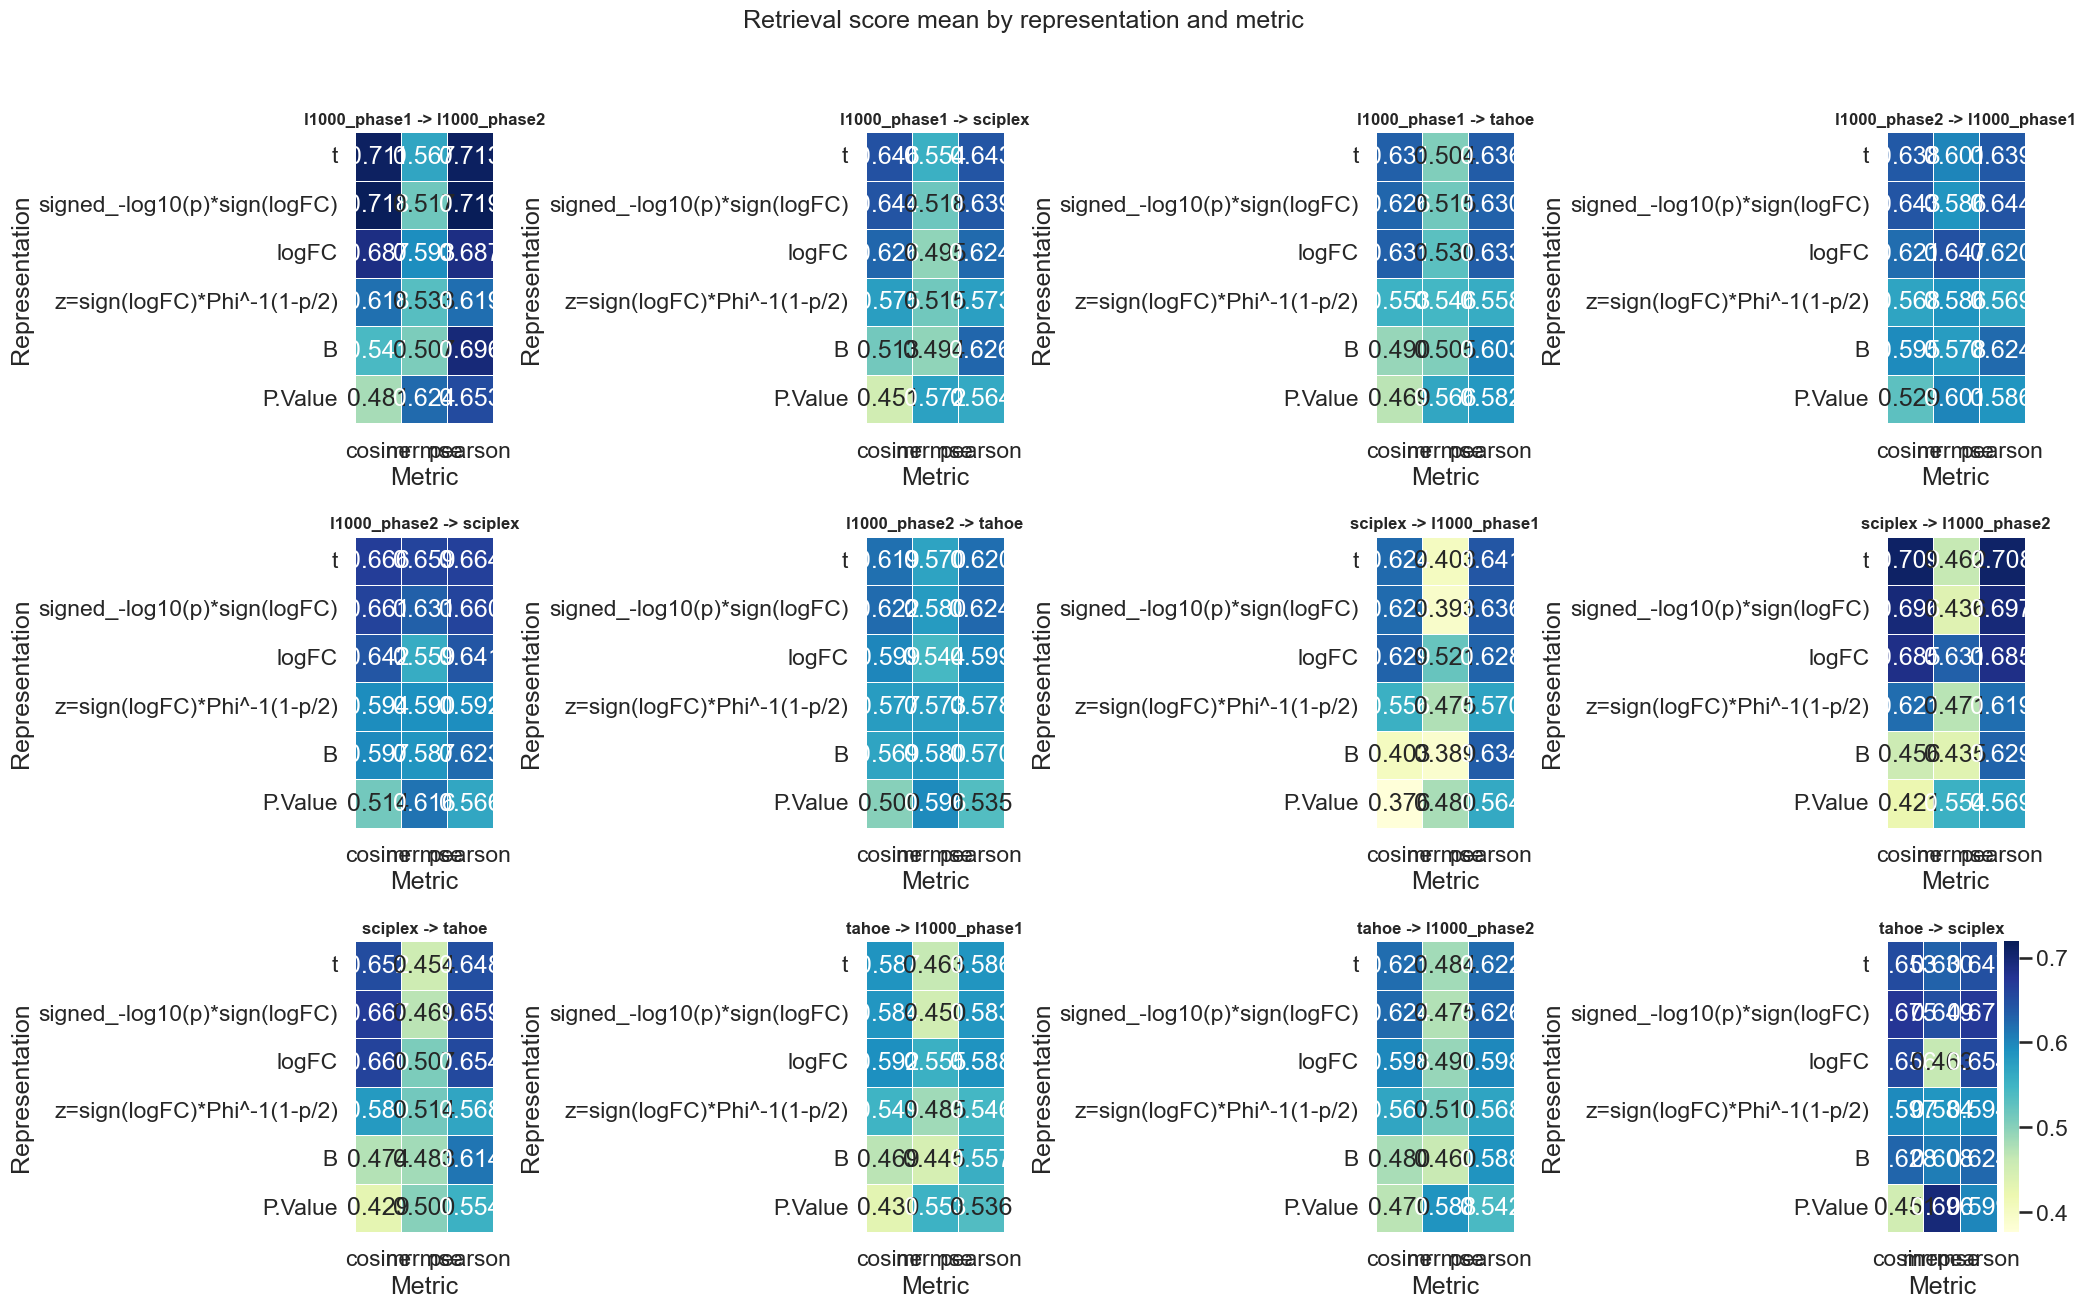

In [28]:
# Overall score heatmaps: one panel per query->db pair.
n_pairs = len(pair_order)
if n_pairs == 0:
    raise ValueError("No dataset pairs found in summary_overall_df.")

ncols = min(4, n_pairs)
nrows = math.ceil(n_pairs / ncols)

vmin = float(summary_overall_df["retrieval_score_mean"].min())
vmax = float(summary_overall_df["retrieval_score_mean"].max())

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5.2 * ncols, 4.3 * nrows))
axes = np.atleast_1d(axes).ravel()

for idx, pair in enumerate(pair_order):
    ax = axes[idx]
    sub = summary_overall_df.loc[summary_overall_df["pair"] == pair]
    pivot = sub.pivot(index="representation", columns="metric", values="retrieval_score_mean")
    pivot = pivot.reindex(index=representation_order, columns=metric_order)
    sns.heatmap(
        pivot,
        ax=ax,
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        linecolor="white",
        cbar=(idx == n_pairs - 1),
    )
    ax.set_title(pair, fontsize=12)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Representation")

for ax in axes[n_pairs:]:
    ax.axis("off")

fig.suptitle("Retrieval score mean by representation and metric", y=1.02, fontsize=18)
plt.tight_layout()
plt.show()
            


Top representation-metric by global average score: signed_-log10(p)*sign(logFC) | pearson
It is the per-pair winner in 3/12 dataset pairs (25.0%).


,representation,metric,n_pairs,avg_retrieval_score_mean,median_retrieval_score_mean,avg_retrieval_score_median,median_retrieval_score_median,pair_win_count,pair_win_fraction
0,signed_-log10(p)*sign(logFC),pearson,12,0.648998,0.641391,0.722706,0.713703,3,0.250000
1,signed_-log10(p)*sign(logFC),cosine,12,0.648648,0.643094,0.721781,0.723556,1,0.083333
2,t,pearson,12,0.647312,0.642022,0.716485,0.699835,2,0.166667
3,t,cosine,12,0.646410,0.641854,0.715148,0.699379,3,0.250000
4,logFC,cosine,12,0.635520,0.629986,0.691397,0.679317,1,0.083333
5,logFC,pearson,12,0.634250,0.630371,0.689348,0.677226,0,0.000000
6,B,pearson,12,0.615621,0.623150,0.667006,0.669697,0,0.000000
7,z=sign(logFC)*Phi^-1(1-p/2),pearson,12,0.579598,0.571685,0.612582,0.603790,0,0.000000
8,z=sign(logFC)*Phi^-1(1-p/2),cosine,12,0.579563,0.575854,0.608554,0.600194,0,0.000000
9,P.Value,mrrmse,12,0.578688,0.580047,0.603922,0.611486,1,0.083333


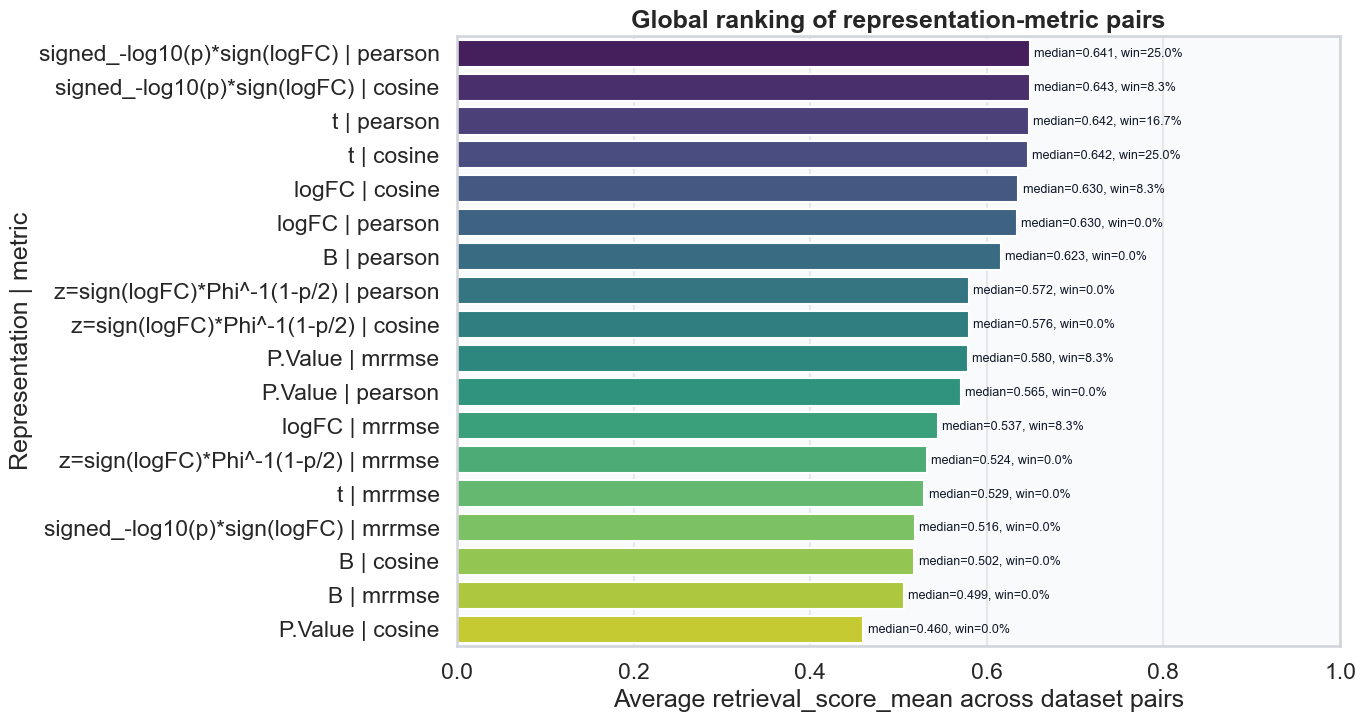

In [29]:
# Compare representation+metric pairs across dataset pairs.
summary_with_config = summary_overall_df.copy()
summary_with_config["config"] = (
    summary_with_config["representation"].astype(str)
    + " | "
    + summary_with_config["metric"].astype(str)
)

config_summary = (
    summary_with_config.groupby(["representation", "metric"], as_index=False)
    .agg(
        n_pairs=("pair", "nunique"),
        avg_retrieval_score_mean=("retrieval_score_mean", "mean"),
        median_retrieval_score_mean=("retrieval_score_mean", "median"),
        avg_retrieval_score_median=("retrieval_score_median", "mean"),
        median_retrieval_score_median=("retrieval_score_median", "median"),
    )
)

pair_winners = (
    summary_with_config.sort_values(
        ["retrieval_score_mean", "retrieval_score_median"],
        ascending=False,
    )
    .groupby(["query_dataset", "db_dataset"], as_index=False)
    .first()
)
winner_share = (
    pair_winners["config"].value_counts(normalize=True)
    .rename("pair_win_fraction")
    .rename_axis("config")
    .reset_index()
)
winner_count = (
    pair_winners["config"].value_counts()
    .rename("pair_win_count")
    .rename_axis("config")
    .reset_index()
)

config_summary["config"] = config_summary["representation"] + " | " + config_summary["metric"]
config_summary = (
    config_summary.merge(winner_count, on="config", how="left")
    .merge(winner_share, on="config", how="left")
    .fillna({"pair_win_count": 0, "pair_win_fraction": 0.0})
)
config_summary["pair_win_count"] = config_summary["pair_win_count"].astype(int)
config_summary = config_summary.sort_values(
    [
        "avg_retrieval_score_mean",
        "median_retrieval_score_mean",
        "avg_retrieval_score_median",
    ],
    ascending=False,
).reset_index(drop=True)

TOP_REPRESENTATION = config_summary.loc[0, "representation"]
TOP_METRIC = config_summary.loc[0, "metric"]
TOP_CONFIG = f"{TOP_REPRESENTATION} | {TOP_METRIC}"

n_pairs_total = pair_winners["pair"].nunique()
top_pair_win_count = int(config_summary.loc[0, "pair_win_count"])
top_pair_win_fraction = float(config_summary.loc[0, "pair_win_fraction"])

print(f"Top representation-metric by global average score: {TOP_CONFIG}")
print(
    f"It is the per-pair winner in {top_pair_win_count}/{n_pairs_total} dataset pairs "
    f"({top_pair_win_fraction:.1%})."
)

display(
    config_summary[
        [
            "representation",
            "metric",
            "n_pairs",
            "avg_retrieval_score_mean",
            "median_retrieval_score_mean",
            "avg_retrieval_score_median",
            "median_retrieval_score_median",
            "pair_win_count",
            "pair_win_fraction",
        ]
    ]
)

plt.figure(figsize=(14, max(5, 0.42 * len(config_summary))))
ax = sns.barplot(
    data=config_summary,
    y="config",
    x="avg_retrieval_score_mean",
    hue="config",
    dodge=False,
    legend=False,
    palette="viridis",
)
ax.set_xlim(0, 1)
ax.set_xlabel("Average retrieval_score_mean across dataset pairs")
ax.set_ylabel("Representation | metric")
ax.set_title("Global ranking of representation-metric pairs")

for i, (_, row) in enumerate(config_summary.iterrows()):
    ax.text(
        min(row["avg_retrieval_score_mean"] + 0.005, 0.995),
        i,
        f"median={row['median_retrieval_score_mean']:.3f}, win={row['pair_win_fraction']:.1%}",
        va="center",
        fontsize=9,
        color="#111827",
    )

plt.tight_layout()
plt.show()


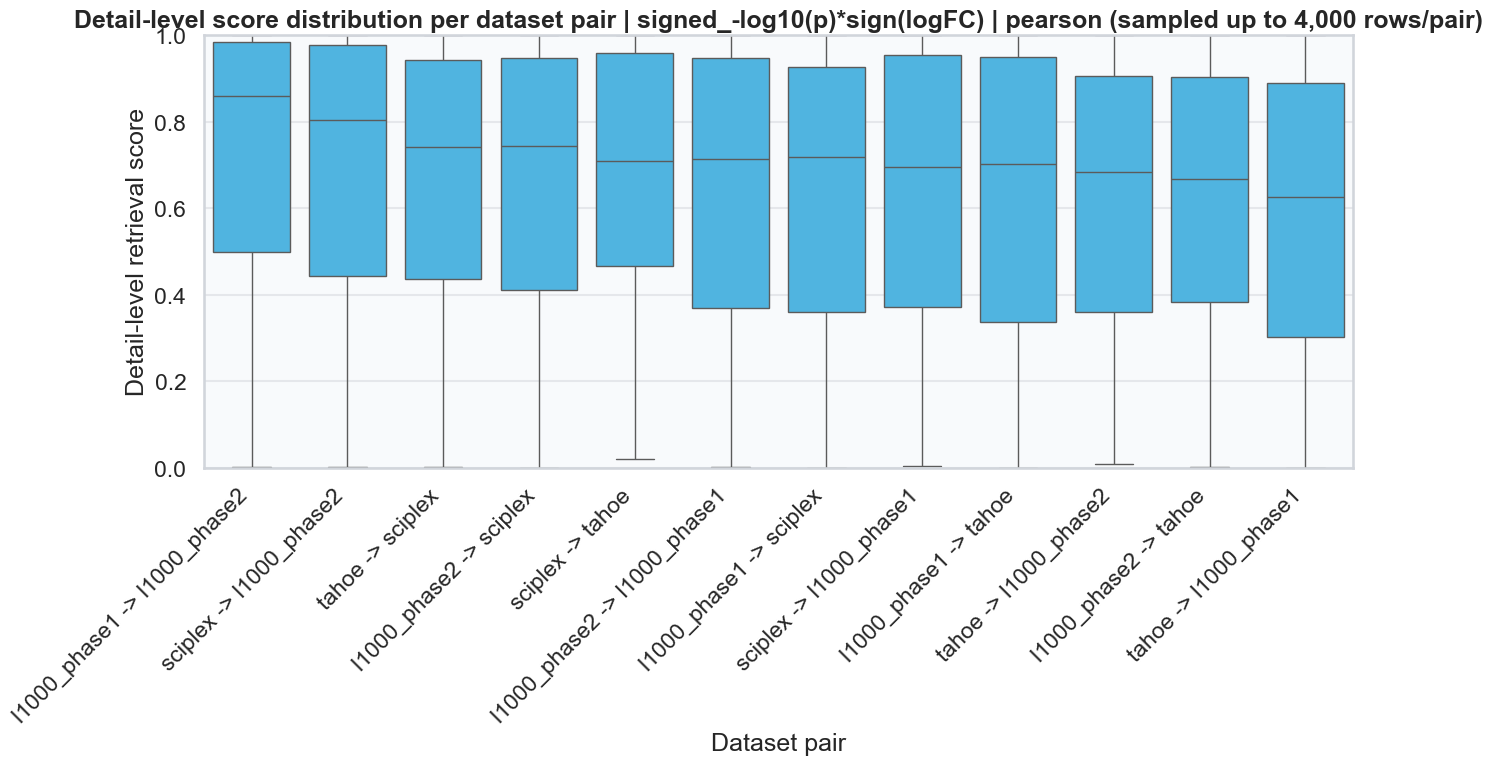

,query_dataset,db_dataset,pair,n_queries,retrieval_score_mean,retrieval_score_median
0,l1000_phase1,l1000_phase2,l1000_phase1 -> l1000_phase2,16358,0.719408,0.857755
1,sciplex,l1000_phase2,sciplex -> l1000_phase2,561,0.696542,0.804917
2,tahoe,sciplex,tahoe -> sciplex,72,0.670911,0.742059
3,l1000_phase2,sciplex,l1000_phase2 -> sciplex,1032,0.659984,0.744249
4,sciplex,tahoe,sciplex -> tahoe,119,0.659304,0.709991
5,l1000_phase2,l1000_phase1,l1000_phase2 -> l1000_phase1,38132,0.643789,0.720983
6,l1000_phase1,sciplex,l1000_phase1 -> sciplex,1005,0.638993,0.717415
7,sciplex,l1000_phase1,sciplex -> l1000_phase1,781,0.635567,0.695623
8,l1000_phase1,tahoe,l1000_phase1 -> tahoe,633,0.630465,0.702918
9,tahoe,l1000_phase2,tahoe -> l1000_phase2,438,0.625735,0.682725


In [30]:
def sample_per_group(df: pd.DataFrame, group_cols: list[str], n_per_group: int, random_state: int = 0) -> pd.DataFrame:
    if n_per_group <= 0:
        return df
    frames = []
    for _, g in df.groupby(group_cols, dropna=False, sort=False):
        if len(g) > n_per_group:
            frames.append(g.sample(n=n_per_group, random_state=random_state))
        else:
            frames.append(g)
    return pd.concat(frames, ignore_index=True) if frames else df


top_detail_df = detail_df[
    (detail_df["representation"] == TOP_REPRESENTATION)
    & (detail_df["metric"] == TOP_METRIC)
].copy()

if top_detail_df.empty:
    raise ValueError(f"No detail rows found for top configuration: {TOP_CONFIG}")

pair_scores_top = summary_overall_df[
    (summary_overall_df["representation"] == TOP_REPRESENTATION)
    & (summary_overall_df["metric"] == TOP_METRIC)
].copy()
pair_scores_top["pair"] = pair_scores_top["query_dataset"] + " -> " + pair_scores_top["db_dataset"]
pair_order_top = pair_scores_top.sort_values("retrieval_score_mean", ascending=False)["pair"].tolist()

sampled_top_detail_df = sample_per_group(
    top_detail_df,
    group_cols=["pair"],
    n_per_group=DETAIL_SAMPLE_PER_GROUP,
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(max(14, 0.7 * len(pair_order_top)), 8))
sns.boxplot(
    data=sampled_top_detail_df,
    x="pair",
    y="retrieval_score",
    order=pair_order_top,
    showfliers=False,
    color="#38BDF8",
    linewidth=1.0,
)
plt.ylim(0, 1)
plt.xlabel("Dataset pair")
plt.ylabel("Detail-level retrieval score")
plt.xticks(rotation=45, ha="right")
plt.title(
    f"Detail-level score distribution per dataset pair | {TOP_CONFIG} "
    f"(sampled up to {DETAIL_SAMPLE_PER_GROUP:,} rows/pair)"
)
plt.tight_layout()
plt.show()

top_detail_pair_stats = (
    top_detail_df.groupby(["query_dataset", "db_dataset", "pair"], as_index=False)
    .agg(
        n_queries=("retrieval_score", "size"),
        retrieval_score_mean=("retrieval_score", "mean"),
        retrieval_score_median=("retrieval_score", "median"),
    )
    .sort_values("retrieval_score_mean", ascending=False)
    .reset_index(drop=True)
)
display(top_detail_pair_stats)


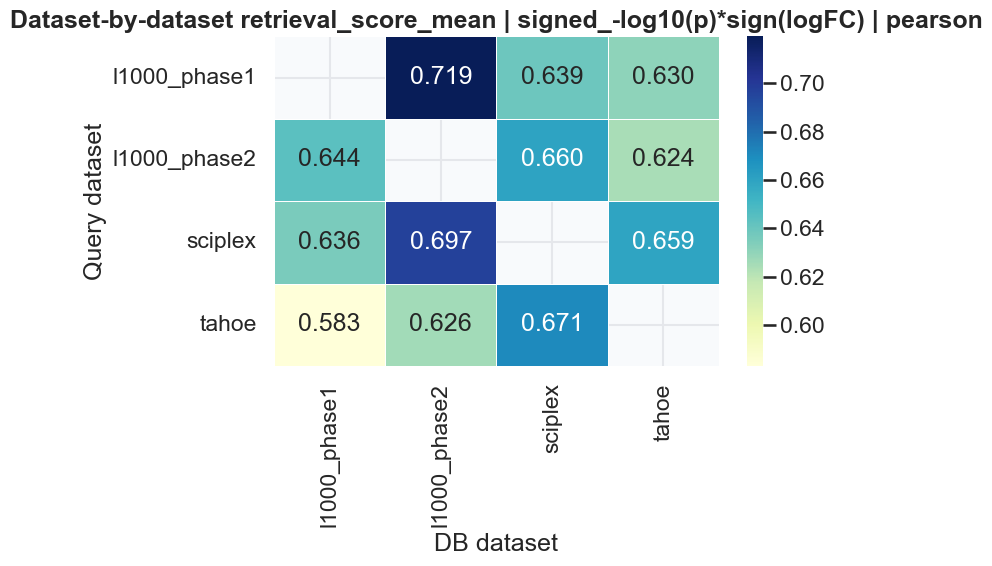

Mean retrieval score by DB dataset (column means):


,db_dataset,db_mean
0,l1000_phase1,0.620788
1,l1000_phase2,0.680562
2,sciplex,0.656629
3,tahoe,0.638012


Mean retrieval score by Query dataset (row means):


,query_dataset,query_mean
0,l1000_phase1,0.662955
1,l1000_phase2,0.642681
2,sciplex,0.663804
3,tahoe,0.626551


Per-dataset score (mean of query_mean and db_mean):


,dataset,query_mean,db_mean,dataset_score_mean_query_db
0,l1000_phase2,0.642681,0.680562,0.661621
1,sciplex,0.663804,0.656629,0.660217
2,l1000_phase1,0.662955,0.620788,0.641872
3,tahoe,0.626551,0.638012,0.632282


,query_dataset,db_dataset,retrieval_score_mean,retrieval_score_median,n_queries
0,l1000_phase1,l1000_phase2,0.719408,0.857755,16358
1,l1000_phase1,sciplex,0.638993,0.717415,1005
2,l1000_phase1,tahoe,0.630465,0.702918,633
3,l1000_phase2,l1000_phase1,0.643789,0.720983,38132
4,l1000_phase2,sciplex,0.659984,0.744249,1032
5,l1000_phase2,tahoe,0.624269,0.668728,1073
6,sciplex,l1000_phase1,0.635567,0.695623,781
7,sciplex,l1000_phase2,0.696542,0.804917,561
8,sciplex,tahoe,0.659304,0.709991,119
9,tahoe,l1000_phase1,0.583008,0.625108,774


In [31]:
# Dataset-by-dataset heatmap for the top representation+metric.
top_summary_df = summary_overall_df[
    (summary_overall_df["representation"] == TOP_REPRESENTATION)
    & (summary_overall_df["metric"] == TOP_METRIC)
].copy()

if top_summary_df.empty:
    raise ValueError(f"No summary rows found for top configuration: {TOP_CONFIG}")

heatmap_df = (
    top_summary_df.pivot(index="query_dataset", columns="db_dataset", values="retrieval_score_mean")
    .sort_index(axis=0)
    .sort_index(axis=1)
)

fig_w = max(8, 1.4 * len(heatmap_df.columns) + 2)
fig_h = max(6, 1.0 * len(heatmap_df.index) + 2)

plt.figure(figsize=(fig_w, fig_h))
sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    vmin=float(top_summary_df["retrieval_score_mean"].min()),
    vmax=float(top_summary_df["retrieval_score_mean"].max()),
)
plt.xlabel("DB dataset")
plt.ylabel("Query dataset")
plt.title(f"Dataset-by-dataset retrieval_score_mean | {TOP_CONFIG}")
plt.tight_layout()
plt.show()


column_means = heatmap_df.mean(axis=0).rename("db_mean").sort_index()
row_means = heatmap_df.mean(axis=1).rename("query_mean").sort_index()

all_datasets = sorted(set(row_means.index).union(set(column_means.index)))
dataset_scores_df = pd.DataFrame({"dataset": all_datasets}).set_index("dataset")
dataset_scores_df["query_mean"] = row_means.reindex(all_datasets)
dataset_scores_df["db_mean"] = column_means.reindex(all_datasets)
dataset_scores_df["dataset_score_mean_query_db"] = dataset_scores_df[["query_mean", "db_mean"]].mean(axis=1)
dataset_scores_df = dataset_scores_df.reset_index()

print("Mean retrieval score by DB dataset (column means):")
display(column_means.reset_index().rename(columns={"index": "db_dataset"}))

print("Mean retrieval score by Query dataset (row means):")
display(row_means.reset_index().rename(columns={"index": "query_dataset"}))

print("Per-dataset score (mean of query_mean and db_mean):")
display(dataset_scores_df.sort_values("dataset_score_mean_query_db", ascending=False).reset_index(drop=True))

display(
    top_summary_df[
        [
            "query_dataset",
            "db_dataset",
            "retrieval_score_mean",
            "retrieval_score_median",
            "n_queries",
        ]
    ]
    .sort_values(["query_dataset", "db_dataset"])
    .reset_index(drop=True)
)


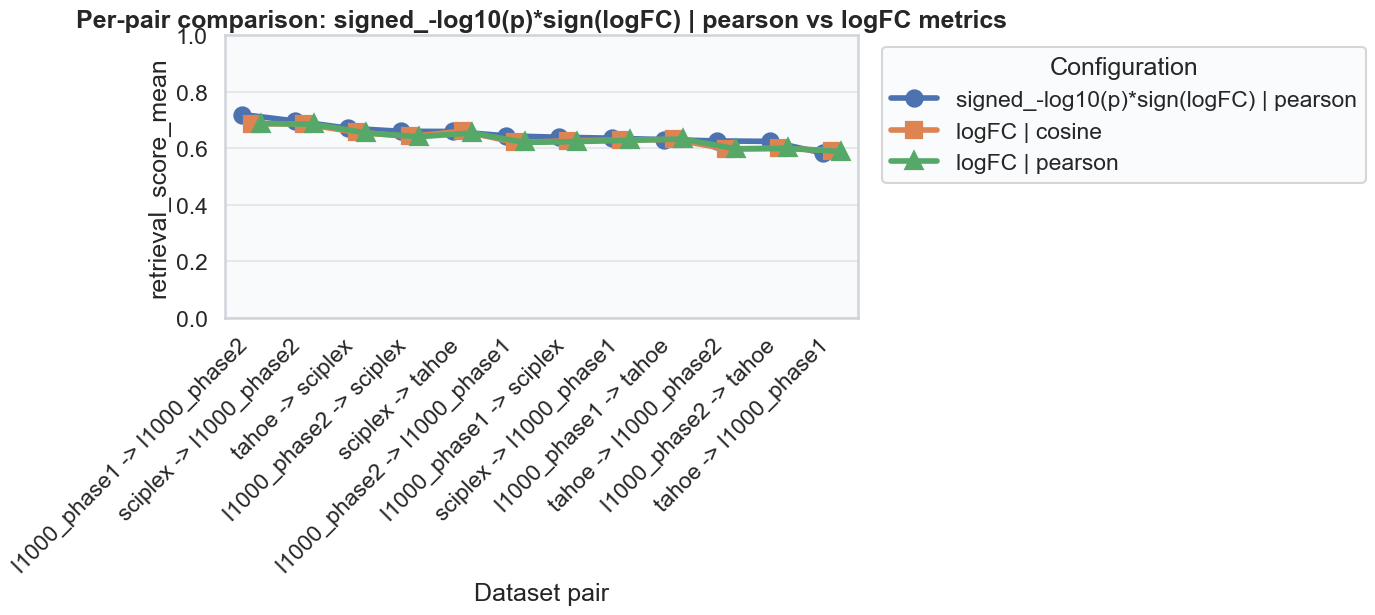

config,pair,signed_-log10(p)*sign(logFC) | pearson,logFC | cosine,logFC | pearson
0,l1000_phase1 -> l1000_phase2,0.719408,0.687497,0.687497
1,sciplex -> l1000_phase2,0.696542,0.685421,0.685011
2,tahoe -> sciplex,0.670911,0.656246,0.653888
3,l1000_phase2 -> sciplex,0.659984,0.641558,0.640793
4,sciplex -> tahoe,0.659304,0.660448,0.653731
5,l1000_phase2 -> l1000_phase1,0.643789,0.620524,0.620443
6,l1000_phase1 -> sciplex,0.638993,0.625803,0.623527
7,sciplex -> l1000_phase1,0.635567,0.628989,0.628217
8,l1000_phase1 -> tahoe,0.630465,0.630983,0.632526
9,tahoe -> l1000_phase2,0.625735,0.597660,0.597609


In [32]:
# Compare the top configuration vs logFC (cosine/pearson) across all dataset pairs.
comparison_df = summary_overall_df.copy()
comparison_df["config"] = comparison_df["representation"].astype(str) + " | " + comparison_df["metric"].astype(str)

comparison_mask = (
    ((comparison_df["representation"] == TOP_REPRESENTATION) & (comparison_df["metric"] == TOP_METRIC))
    | ((comparison_df["representation"] == "logFC") & (comparison_df["metric"].isin(["cosine", "pearson"])))
)
comparison_df = comparison_df.loc[comparison_mask].copy()

comparison_configs = list(dict.fromkeys([TOP_CONFIG, "logFC | cosine", "logFC | pearson"]))
comparison_df["config"] = pd.Categorical(comparison_df["config"], categories=comparison_configs, ordered=True)
comparison_df = comparison_df.dropna(subset=["config"]).copy()

pair_order_compare = (
    comparison_df.loc[comparison_df["config"] == TOP_CONFIG]
    .sort_values("retrieval_score_mean", ascending=False)["pair"]
    .tolist()
)
remaining_pairs = [p for p in sorted(comparison_df["pair"].unique().tolist()) if p not in pair_order_compare]
pair_order_compare = pair_order_compare + remaining_pairs

plt.figure(figsize=(max(14, 0.85 * len(pair_order_compare)), 6.5))
sns.pointplot(
    data=comparison_df,
    x="pair",
    y="retrieval_score_mean",
    hue="config",
    order=pair_order_compare,
    errorbar=None,
    dodge=0.35,
    markers=["o", "s", "^"][: len(comparison_configs)],
    linestyles="-",
)
plt.ylim(0, 1)
plt.xlabel("Dataset pair")
plt.ylabel("retrieval_score_mean")
plt.xticks(rotation=45, ha="right")
plt.title(f"Per-pair comparison: {TOP_CONFIG} vs logFC metrics")
plt.legend(title="Configuration", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

comparison_pivot = (
    comparison_df.pivot_table(index="pair", columns="config", values="retrieval_score_mean", observed=False)
    .reindex(pair_order_compare)
    .reset_index()
)
display(comparison_pivot)


Task detail files found: 360/360 (100.0%)


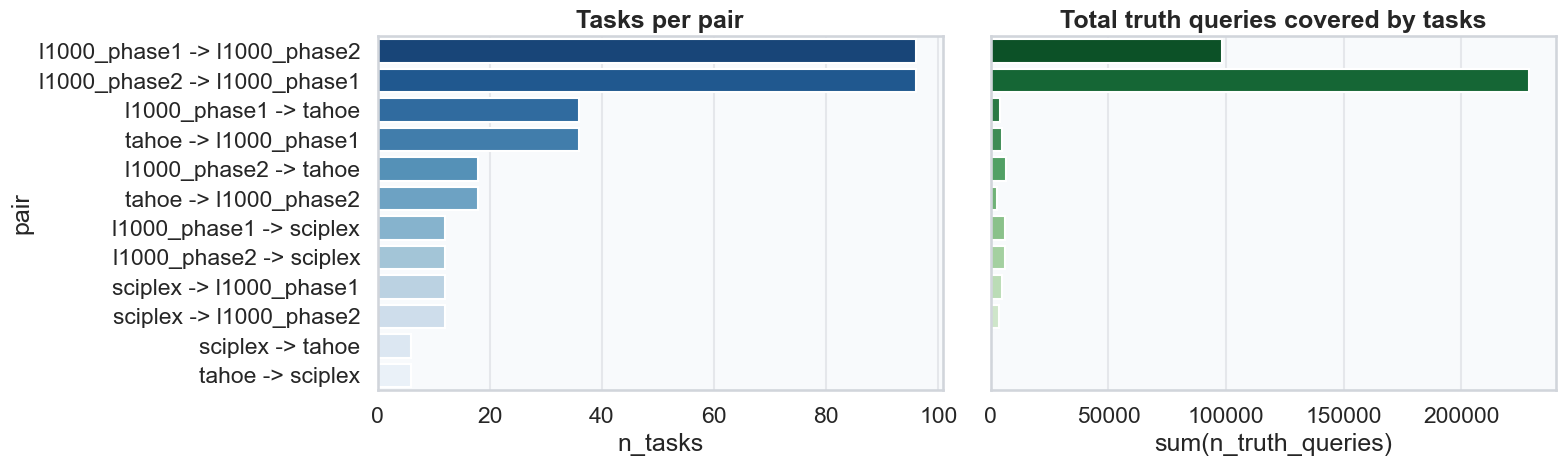

,pair,n_tasks,n_truth_queries
0,l1000_phase1 -> l1000_phase2,96,98148
3,l1000_phase2 -> l1000_phase1,96,228792
2,l1000_phase1 -> tahoe,36,3798
9,tahoe -> l1000_phase1,36,4644
5,l1000_phase2 -> tahoe,18,6438
10,tahoe -> l1000_phase2,18,2628
1,l1000_phase1 -> sciplex,12,6030
4,l1000_phase2 -> sciplex,12,6192
6,sciplex -> l1000_phase1,12,4686
7,sciplex -> l1000_phase2,12,3366


,pair,n_cell_types,n_truth_queries,mean_shared_cids
3,l1000_phase2 -> l1000_phase1,16,38132,316.000000
0,l1000_phase1 -> l1000_phase2,16,16358,316.000000
5,l1000_phase2 -> tahoe,3,1073,47.666667
4,l1000_phase2 -> sciplex,2,1032,64.000000
1,l1000_phase1 -> sciplex,2,1005,88.500000
6,sciplex -> l1000_phase1,2,781,88.500000
9,tahoe -> l1000_phase1,6,774,42.833333
2,l1000_phase1 -> tahoe,6,633,42.833333
7,sciplex -> l1000_phase2,2,561,64.000000
10,tahoe -> l1000_phase2,3,438,47.666667


In [33]:
if tasks_df.empty and truth_summary_df.empty:
    print("No tasks/truth files found for this run. Skipping diagnostics.")
else:
    if not tasks_df.empty:
        task_dir = results_dir / "tasks"
        tasks_diag = tasks_df.copy()
        tasks_diag["detail_file_exists"] = tasks_diag["task_detail_file"].apply(
            lambda x: (task_dir / str(x)).exists() if pd.notna(x) and str(x).strip() else False
        )
        completion = tasks_diag["detail_file_exists"].mean()
        print(
            f"Task detail files found: {tasks_diag['detail_file_exists'].sum():,}/{len(tasks_diag):,} "
            f"({completion:.1%})"
        )

        tasks_per_pair = (
            tasks_diag.groupby("pair", as_index=False)
            .agg(
                n_tasks=("task_id", "count"),
                n_truth_queries=("n_truth_queries", "sum"),
            )
            .sort_values("n_tasks", ascending=False)
        )

        fig, axes = plt.subplots(1, 2, figsize=(16, max(5, 0.32 * len(tasks_per_pair))), sharey=True)
        sns.barplot(
            data=tasks_per_pair,
            y="pair",
            x="n_tasks",
            hue="pair",
            dodge=False,
            legend=False,
            ax=axes[0],
            palette="Blues_r",
        )
        axes[0].set_title("Tasks per pair")
        axes[0].set_xlabel("n_tasks")
        axes[0].set_ylabel("pair")

        sns.barplot(
            data=tasks_per_pair,
            y="pair",
            x="n_truth_queries",
            hue="pair",
            dodge=False,
            legend=False,
            ax=axes[1],
            palette="Greens_r",
        )
        axes[1].set_title("Total truth queries covered by tasks")
        axes[1].set_xlabel("sum(n_truth_queries)")
        axes[1].set_ylabel("")

        plt.tight_layout()
        plt.show()

        display(tasks_per_pair.head(20))

    if not truth_summary_df.empty:
        truth_by_pair = (
            truth_summary_df.groupby("pair", as_index=False)
            .agg(
                n_cell_types=("query_cell_type", "nunique"),
                n_truth_queries=("n_truth_queries", "sum"),
                mean_shared_cids=("n_shared_pubchem_cids", "mean"),
            )
            .sort_values("n_truth_queries", ascending=False)
        )
        display(truth_by_pair)
            
